# Feature engineering

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

In [2]:
data_path = "eda_dataset.csv"
df = pd.read_csv(data_path, parse_dates=["InvoiceDate"])
print(df.shape)
df.head()

(401564, 11)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,is_return,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34


In [3]:
print(sorted(df["Quantity"].unique()))

[-80995, -74215, -9360, -3114, -2000, -1930, -1515, -1350, -1300, -1296, -1200, -960, -840, -828, -756, -720, -701, -670, -624, -600, -576, -500, -480, -468, -432, -420, -408, -400, -360, -334, -324, -318, -312, -300, -288, -276, -252, -250, -244, -240, -234, -220, -200, -192, -186, -184, -180, -168, -164, -162, -160, -152, -150, -144, -140, -132, -130, -126, -121, -120, -113, -112, -110, -108, -102, -100, -96, -94, -86, -85, -82, -80, -79, -76, -75, -72, -70, -68, -67, -66, -64, -60, -58, -53, -52, -51, -50, -49, -48, -47, -46, -45, -43, -42, -40, -39, -38, -37, -36, -35, -34, -33, -32, -31, -30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 62, 63, 64, 65, 66, 67, 69, 

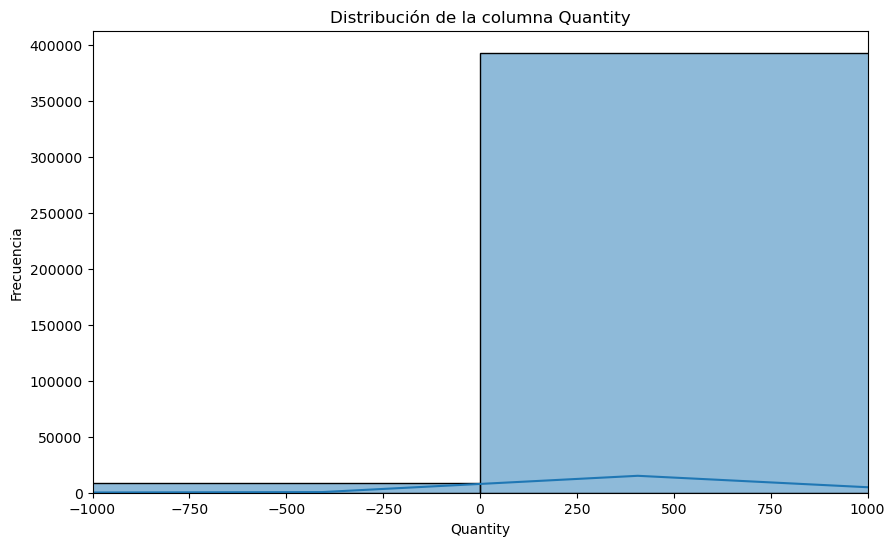

In [4]:
plt.figure(figsize=(10,6))
sns.histplot(df['Quantity'], bins=30, kde=True)  # kde=True agrega una curva de densidad
plt.xlim(-1000, 1000) 
plt.title('Distribución de la columna Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frecuencia')
plt.show()

### Defino ventanas temporales

In [5]:
OBS_END = pd.Timestamp("2011-08-31")
PRED_START = pd.Timestamp("2011-09-01")
PRED_END = pd.Timestamp("2011-12-09")

In [6]:
df_obs = df[df["InvoiceDate"] <= OBS_END].copy()
df_pred = df[
    (df["InvoiceDate"] >= PRED_START) &
    (df["InvoiceDate"] <= PRED_END)
].copy()

Features → df_obs | Target → df_pred

### Se construyeron las variables clásicas RFM, ampliamente utilizadas en análisis de clientes:
 
- Recency: número de días desde la última compra del cliente hasta el final de la ventana de observación.
- Frequency: número de compras únicas realizadas por el cliente.
- Monetary: gasto total acumulado del cliente durante el periodo de observación.

Estas variables proporcionan una primera caracterización del nivel de actividad y valor del cliente.

Creo RECENCY como días desde la última compra hasta el final de la ventana de observación

In [7]:
last_purchase = (
    df_obs.groupby("CustomerID")["InvoiceDate"]
          .max()
)

recency = (OBS_END - last_purchase).dt.days


FREQUENCY: Número de compras únicas(facturas)

In [8]:
frequency = (
    df_obs.groupby("CustomerID")["InvoiceNo"]
          .nunique()
)

MONETARY: Gasto total(excluyendo devoluciones netas negativas)

In [9]:
monetary = (
    df_obs.groupby("CustomerID")["TotalPrice"]
          .sum()
)

### Nuevas variables

TICKET MEDIO: valor medio de las compras realizadas por el cliente.

In [10]:
avg_basket = (
    df_obs.groupby(["CustomerID", "InvoiceNo"])["TotalPrice"]
          .sum()
          .groupby("CustomerID")
          .mean()
)

VARIABILIDAD DEL GASTO: desviación estándar del valor de las compras, capturando estabilidad o irregularidad en el comportamiento.

In [11]:
std_basket = (
    df_obs.groupby(["CustomerID", "InvoiceNo"])["TotalPrice"]
          .sum()
          .groupby("CustomerID")
          .std()
          .fillna(0)
)


RATIO DE DEVOLUCIONES: proporción de transacciones asociadas a devoluciones, útil como indicador de fricción o insatisfacción.

In [12]:
returns_ratio = (
    df_obs.groupby("CustomerID")["is_return"]
          .mean()
)

TIEMPO MEDIO ENTRE COMPRAS: promedio de días entre compras consecutivas, como proxy de recurrencia.

In [13]:
purchase_intervals = (
    df_obs.sort_values("InvoiceDate")
          .groupby("CustomerID")["InvoiceDate"]
          .diff()
          .dt.days
)

avg_interpurchase_time = (
    purchase_intervals.groupby(df_obs["CustomerID"])
                      .mean()
)

Construcción del dataset final de features

In [14]:
features = pd.DataFrame({
    "recency": recency,
    "frequency": frequency,
    "monetary": monetary,
    "avg_basket": avg_basket,
    "std_basket": std_basket,
    "returns_ratio": returns_ratio,
    "avg_interpurchase_time": avg_interpurchase_time
})


In [15]:
display(features)
features.describe().T

,recency,frequency,monetary,avg_basket,std_basket,returns_ratio,avg_interpurchase_time
CustomerID,,,,,,,
12346,224,2,0.00,0.000000,109154.093913,0.500000,0.000000
12347,28,5,2790.86,558.172000,130.495277,0.000000,1.910569
12348,147,3,1487.24,495.746667,350.867155,0.000000,4.037037
12350,209,1,334.40,334.400000,0.000000,0.000000,0.000000
12352,161,8,601.18,75.147500,410.783764,0.208333,0.723404
...,...,...,...,...,...,...,...
18280,176,1,180.60,180.600000,0.000000,0.000000,0.000000
18281,79,1,80.82,80.820000,0.000000,0.000000,0.000000
18282,21,2,98.76,49.380000,71.884475,0.125000,0.571429


,count,mean,std,min,25%,50%,75%,max
recency,3355.0,91.208644,77.137113,0.00,26.000,71.000000,145.000000,272.000000
frequency,3355.0,4.101341,6.812672,1.00,1.000,2.000000,4.000000,134.000000
monetary,3355.0,1459.384975,5550.250325,-4287.63,239.980,529.430000,1310.665000,176104.540000
avg_basket,3355.0,306.595416,373.920995,-4287.63,142.424,226.240000,352.427857,6149.613125
std_basket,3355.0,205.442694,2000.826089,0.00,0.000,71.446069,201.108563,109154.093913
returns_ratio,3355.0,0.038601,0.129483,0.00,0.000,0.000000,0.023256,1.000000
avg_interpurchase_time,3275.0,2.605527,9.183666,0.00,0.000,0.812500,2.394338,245.000000


### LIMPIEZA A NIVEL CLIENTE
Decisión: imputar con un valor alto (cliente esporádico).
Se identificaron clientes con una única compra, para los cuales el tiempo entre compras no está definido. En estos casos, la variable se imputó con un valor alto representativo de clientes esporádicos, evitando eliminar observaciones y manteniendo coherencia semántica.

In [16]:
features["avg_interpurchase_time"] = (
    features["avg_interpurchase_time"]
    .fillna(features["avg_interpurchase_time"].max())
)


Transformaciones (preparación para clustering) Dado el fuerte sesgo presente en variables monetarias y de volumen, se aplicaron transformaciones logarítmicas para estabilizar las distribuciones y reducir la influencia de valores extremos.

In [17]:
skewed_cols = ["monetary", "avg_basket", "std_basket"]

for col in skewed_cols:
    features[col] = np.log1p(features[col].clip(lower=0))


Posteriormente, todas las variables fueron escaladas utilizando Robust Scaling, una técnica basada en mediana e intervalo intercuartílico, especialmente adecuada para datos con outliers, como es habitual en e-commerce.

In [18]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
features_scaled = pd.DataFrame(
    scaler.fit_transform(features),
    index=features.index,
    columns=features.columns
)


In [19]:
display(features_scaled)

,recency,frequency,monetary,avg_basket,std_basket,returns_ratio,avg_interpurchase_time
CustomerID,,,,,,,
12346,1.285714,0.000000,-3.702736,-6.016369,1.378405,21.500000,-0.347901
12347,-0.361345,1.000000,0.980191,0.998421,0.112291,0.000000,0.397971
12348,0.638655,0.333333,0.608887,0.867165,0.297696,0.000000,1.228129
12350,1.159664,-0.333333,-0.270527,0.431676,-0.806743,0.000000,-0.347901
12352,0.756303,2.000000,0.074878,-1.212292,0.327316,8.958333,-0.065489
...,...,...,...,...,...,...,...
18280,0.882353,-0.333333,-0.632625,-0.248594,-0.806743,0.000000,-0.347901
18281,0.067227,-0.333333,-1.103183,-1.132625,-0.806743,0.000000,-0.347901
18282,-0.420168,0.000000,-0.986179,-1.670314,0.001136,5.375000,-0.124819


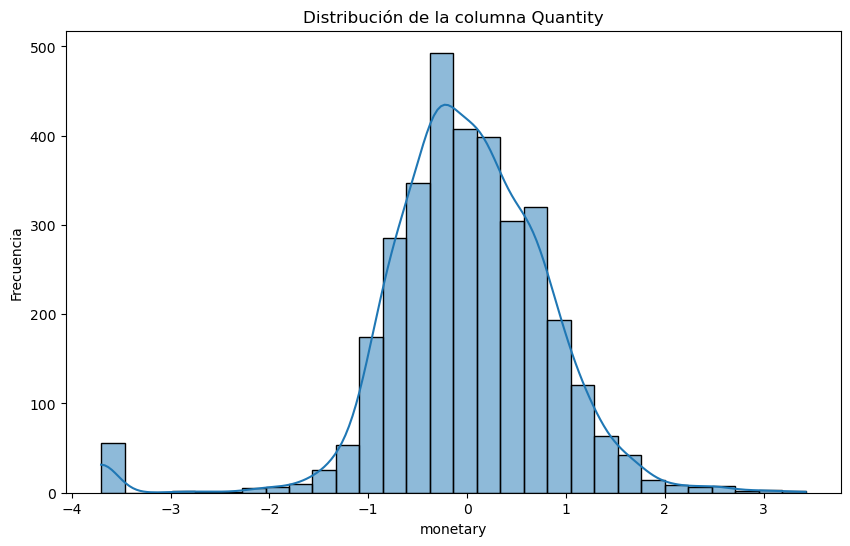

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(features_scaled['monetary'], bins=30, kde=True)  # kde=True agrega una curva de densidad
plt.title('Distribución de la columna Quantity')
plt.xlabel('monetary')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
# features_scaled.to_csv(
#     "feature_engineering_dataset.csv"
# )